In [279]:
import os
import sys
import argparse
import time
import numpy as np
import pandas as pd
from typing import Optional, Set, List
from datetime import datetime
import pyarrow.parquet as pq
# Optional SciPy / Matplotlib imports
try:
    from scipy.stats import genextreme, kstest, probplot
    SCIPY_OK = True
except Exception:
    SCIPY_OK = False

try:
    import matplotlib.pyplot as plt
    MPL_OK = True
except Exception:
    MPL_OK = False



In [299]:
METRICS      = ("producer_consumer", "consumer_application", "producer_application")
SCOPES       = ("global", "consumer_pod", "producer_pod")
SCOPE        = "global"
Home         = "/Users/soheila/PycharmProjects/PipelineProject/RealTime-Streaming-Pipeline/results"
RUN_STAMP    = "20250902_143113"             
PARQUET_ROOT = os.path.join(Home, RUN_STAMP, "consumer", "consumer-sts-0_consumer-result")
metrics_dir  = os.path.join(Home, RUN_STAMP, "merge", "merge-sts-0_merge-metrics")
block_path   = os.path.join(metrics_dir, "block_maxima.csv")
trim_levels  = [0.00, 0.01, 0.02, 0.05, 0.07, 0.10] 

In [300]:
# -----------------------------
# Helpers
# -----------------------------
def list_parquet_files(root: str):
    out = []
    for r, _, fs in os.walk(root):
        for f in fs:
            if f.endswith(".parquet") and not f.startswith(".tmp_"):
                out.append(os.path.join(r, f))
    return sorted(out)


In [301]:
len(list_parquet_files(PARQUET_ROOT))

708

In [302]:
def load_parquet_columns(parquet_path: str, needed_cols):
    needed = set(needed_cols)
    try:
        have = set(pq.read_schema(parquet_path).names)
        cols = list(needed & have)
        if not cols:
            return pd.DataFrame()
        return pd.read_parquet(parquet_path, columns=cols)
    except Exception:
        try:
            df = pd.read_parquet(parquet_path)
            keep = list(needed & set(df.columns))
            return df[keep] if keep else pd.DataFrame()
        except Exception as e2:
            print(f"[ERROR] Failed to read {os.path.basename(parquet_path)}: {e2}")
            return None

In [303]:
needed = { 
        "producer_timestamp", "consumer_receive_timestamp",
        "application_timestamp", "application_latency_seconds",
        "end_to_end_latency_seconds", "target_rate" , 
        "producer_pod", "consumer_pod",
    }

In [304]:
df = load_parquet_columns(PARQUET_ROOT , needed)

In [309]:
df["target_rate"].unique()[0]

75.0

In [310]:
# -----------------------------
# Load Parquet Files
# -----------------------------
def build_block_metadata_map(root_dir):
    """
    Returns a DataFrame indexed by block_id (filename sans .parquet)
    with at least the column 'target_rate' (mode per file).
    """
    files = list_parquet_files(root_dir)
    rows = []
    for p in files:
        try:
            df = pd.read_parquet(p, columns=["target_rate"])
        except Exception:
            # fallback: read all, then subset if present
            try:
                df = pd.read_parquet(p)
            except Exception:
                continue
        if "target_rate" not in df.columns or df["target_rate"].dropna().empty:
            continue
        tr = pd.to_numeric(df["target_rate"], errors="coerce").dropna()
        if tr.empty:
            continue
        block_id = os.path.splitext(os.path.basename(p))[0]
        rows.append({"block_id": block_id, "target_rate": float(tr.mode().iloc[0])})
    if not rows:
        return pd.DataFrame()
    md = pd.DataFrame(rows).drop_duplicates("block_id").set_index("block_id")
    return md
    


In [311]:
# -----------------------------
# Load block_maxima
# -----------------------------
if not os.path.exists(block_path):
    raise FileNotFoundError(f"block_maxima.csv not found at: {block_path}")

block_df = pd.read_csv(block_path)


In [312]:
# Add a block_id to parquet data frame
if "block_id" not in block_df.columns:
    if "file_name" not in block_df.columns:
        raise ValueError("block_maxima.csv missing both 'block_id' and 'file_name'.")
    block_df["block_id"] = (
        block_df["file_name"].astype(str).str.replace(r"\.parquet$", "", regex=True)
    )
    print("[INFO] Derived block_id from file_name.")
block_df["block_id"] = block_df["block_id"].astype(str)

[INFO] Derived block_id from file_name.


In [313]:
#print(block_df)
TARGET_RATE  = df["target_rate"].unique()[0]

In [314]:
# Get per-block target_rate from THIS RUN's parquet tree
meta_df = build_block_metadata_map(PARQUET_ROOT)

if meta_df is None or meta_df.empty:
    print("⚠️  Could not build parquet metadata; proceeding without target_rate filter.")
else:
    # merge on block_id
    block_df = block_df.merge(meta_df, left_on="block_id", right_index=True, how="left")
    if "target_rate" in block_df.columns:
        block_df["target_rate"] = pd.to_numeric(block_df["target_rate"], errors="coerce")
    print("[INFO] After merge, target_rate value counts (top 8):")
    print(block_df["target_rate"].value_counts(dropna=False).head(8))
    
#print(meta_df)
#print(block_df)

[INFO] After merge, target_rate value counts (top 8):
target_rate
75.0    420255
Name: count, dtype: int64



Metric=producer_consumer | Scope=global | TARGET_RATE=75.0 | n=140085
GEV fit: c=-0.4191, loc=1.0420, scale=0.1573 | KS D=0.1517, p=0.0000


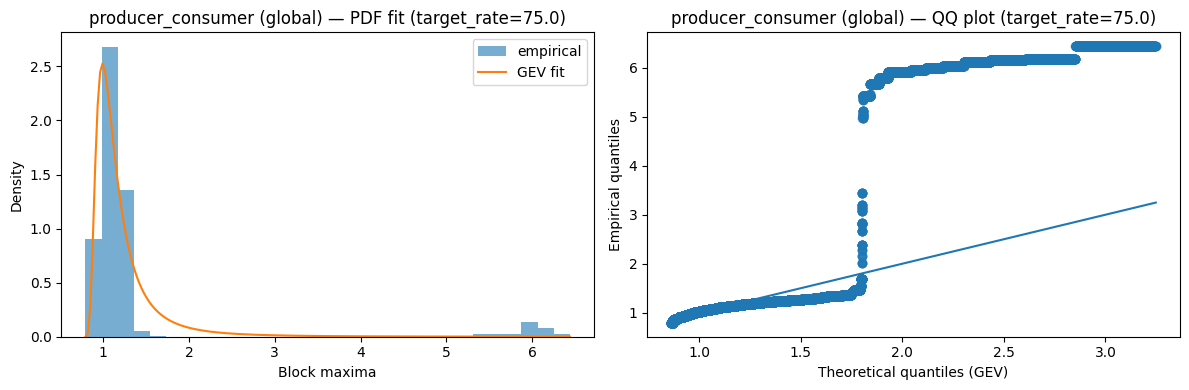

[INFO] Saved plot to /Users/soheila/PycharmProjects/PipelineProject/RealTime-Streaming-Pipeline/results/plots/plots_tr75.0/pdfqq_producer_consumer_global_tr75.0.png

Metric=consumer_application | Scope=global | TARGET_RATE=75.0 | n=140085
GEV fit: c=0.9779, loc=0.0200, scale=0.0000 | KS D=0.0268, p=0.0000


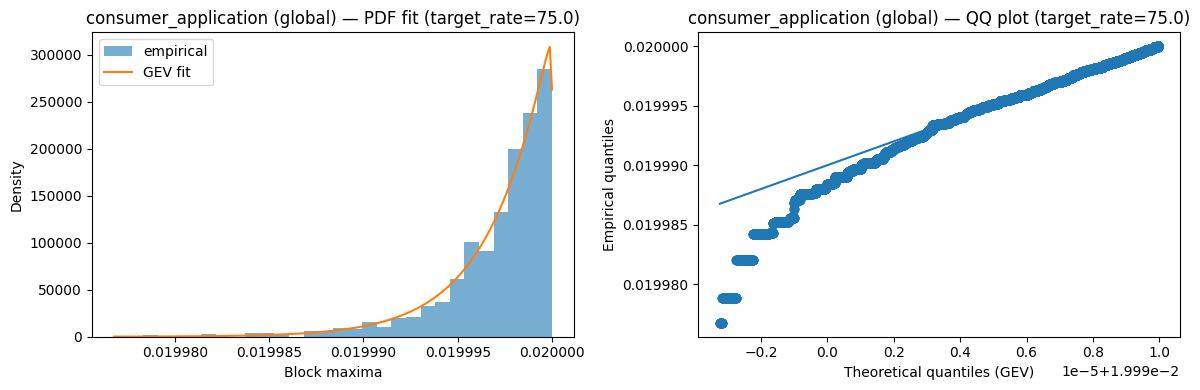

[INFO] Saved plot to /Users/soheila/PycharmProjects/PipelineProject/RealTime-Streaming-Pipeline/results/plots/plots_tr75.0/pdfqq_consumer_application_global_tr75.0.png

Metric=producer_application | Scope=global | TARGET_RATE=75.0 | n=140085
GEV fit: c=-0.4261, loc=1.0538, scale=0.1560 | KS D=0.1492, p=0.0000


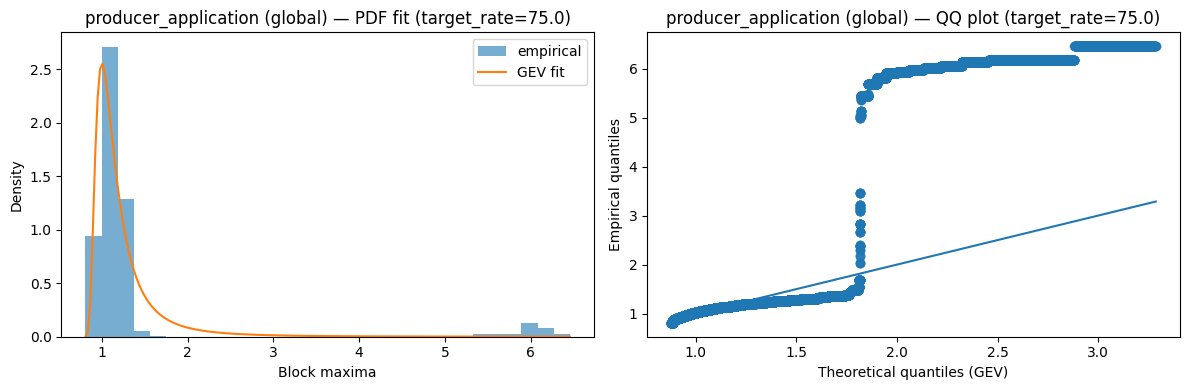

[INFO] Saved plot to /Users/soheila/PycharmProjects/PipelineProject/RealTime-Streaming-Pipeline/results/plots/plots_tr75.0/pdfqq_producer_application_global_tr75.0.png


In [315]:
# -----------------------------
# Fit & Plot per metric
# -----------------------------

SCOPE    = "global"
metrics  = ["producer_consumer", "consumer_application", "producer_application"]
plot_dir = os.path.join(Home,"plots", f"plots_tr{TARGET_RATE}")
os.makedirs(plot_dir, exist_ok=True)

for metric in metrics:
    mask = (block_df["metric"] == metric)
    nrows = int(mask.sum())
    if nrows == 0:
        print(f"⚠️  No rows for metric={metric} at scope={SCOPE}.")
        continue

    data = block_df.loc[mask, "block_max_value"].dropna().astype(float).values
    if len(data) < 5:
        print(f"⚠️  Not enough data for metric={metric} (n={len(data)}). Skipping.")
        continue

    # Fit GEV + KS
    c, loc, scale = genextreme.fit(data)
    D, p = kstest(data, 'genextreme', args=(c, loc, scale))
    print(f"\nMetric={metric} | Scope={SCOPE} | TARGET_RATE={TARGET_RATE} | n={len(data)}")
    print(f"GEV fit: c={c:.4f}, loc={loc:.4f}, scale={scale:.4f} | KS D={D:.4f}, p={p:.4f}")

    # ---- Plot (one figure per metric) ----
    fig = plt.figure(figsize=(12, 4))
    
    # Left: histogram + fitted PDF
    ax1 = plt.subplot(1, 2, 1)
    x = np.linspace(float(np.min(data)), float(np.max(data)), 200)
    pdf = genextreme.pdf(x, c, loc=loc, scale=scale)
    ax1.hist(data, bins=30, density=True, alpha=0.6, label="empirical")
    ax1.plot(x, pdf, label="GEV fit")
    ax1.set_title(f"{metric} ({SCOPE}) — PDF fit (target_rate={TARGET_RATE})")
    ax1.set_xlabel("Block maxima")
    ax1.set_ylabel("Density")
    ax1.legend()

    # Right: QQ-plot
    ax2 = plt.subplot(1, 2, 2)
    emp_q = np.sort(data)
    theo_q = genextreme.ppf(np.linspace(0.01, 0.99, len(emp_q)), c, loc=loc, scale=scale)
    ax2.scatter(theo_q, emp_q, alpha=0.6)
    lo, hi = np.nanmin(theo_q), np.nanmax(theo_q)
    ax2.plot([lo, hi], [lo, hi])
    ax2.set_title(f"{metric} ({SCOPE}) — QQ plot (target_rate={TARGET_RATE})")
    ax2.set_xlabel("Theoretical quantiles (GEV)")
    ax2.set_ylabel("Empirical quantiles")

    plt.tight_layout()

    out_path = os.path.join(plot_dir, f"pdfqq_{metric}_{SCOPE}_tr{TARGET_RATE}.png")
    plt.savefig(out_path, dpi=150)
    plt.show()
    print(f"[INFO] Saved plot to {out_path}")


In [316]:
def trim_top_pct(arr, pct):
    if pct <= 0:
        return arr
    cut = np.nanpercentile(arr, 100 * (1.0 - pct))
    return arr[arr <= cut]
    
def fit_and_ks(x):
    c, loc, scale = genextreme.fit(x)
    D, p = kstest(x, 'genextreme', args=(c, loc, scale))
    return c, loc, scale, D, p


=== producer_consumer (scope=global, target_rate=75.0) ===
 trim=  0%: n=140085  KS D=0.1517  p=0.0000  (c=-0.4191, loc=1.0420, scale=0.1573)
 trim=  1%: n=138700  KS D=0.1442  p=0.0000  (c=-0.3809, loc=1.0401, scale=0.1505)
 trim=  2%: n=137312  KS D=0.1354  p=0.0000  (c=-0.3386, loc=1.0384, scale=0.1437)
 trim=  5%: n=133149  KS D=0.0925  p=0.0000  (c=-0.1545, loc=1.0362, scale=0.1221)
 trim=  7%: n=130485  KS D=0.0248  p=0.0000  (c=+0.2870, loc=1.0542, scale=0.1147)
 trim= 10%: n=126144  KS D=0.0321  p=0.0000  (c=+0.3872, loc=1.0537, scale=0.1119)


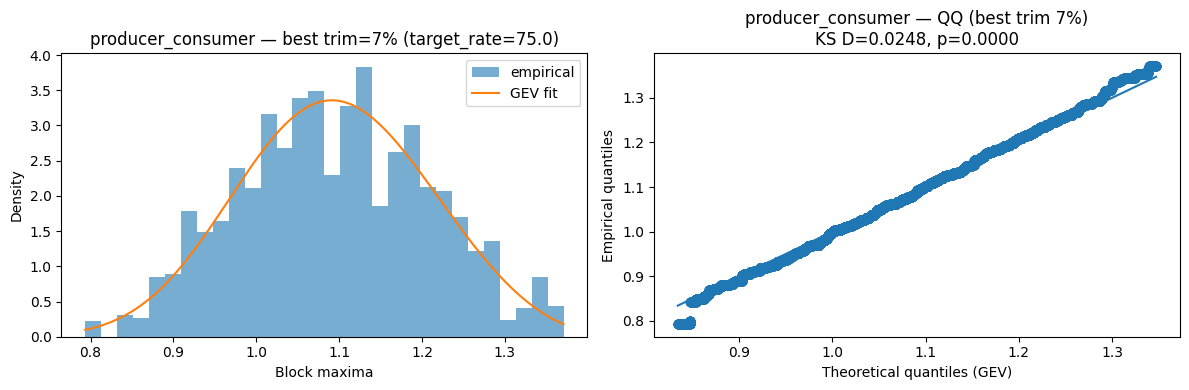

[PLOT] Saved /Users/soheila/PycharmProjects/PipelineProject/RealTime-Streaming-Pipeline/results/plots/best_producer_consumer_trim7_tr75.0_global.png

=== consumer_application (scope=global, target_rate=75.0) ===
 trim=  0%: n=140085  KS D=0.0268  p=0.0000  (c=+0.9779, loc=0.0200, scale=0.0000)
 trim=  1%: n=138775  KS D=0.0244  p=0.0000  (c=+0.9887, loc=0.0200, scale=0.0000)
 trim=  2%: n=137294  KS D=0.0270  p=0.0000  (c=+0.9801, loc=0.0200, scale=0.0000)
 trim=  5%: n=133151  KS D=0.0249  p=0.0000  (c=+0.9961, loc=0.0200, scale=0.0000)
 trim=  7%: n=130395  KS D=0.0282  p=0.0000  (c=+1.0250, loc=0.0200, scale=0.0000)
 trim= 10%: n=126133  KS D=0.0259  p=0.0000  (c=+1.0008, loc=0.0200, scale=0.0000)


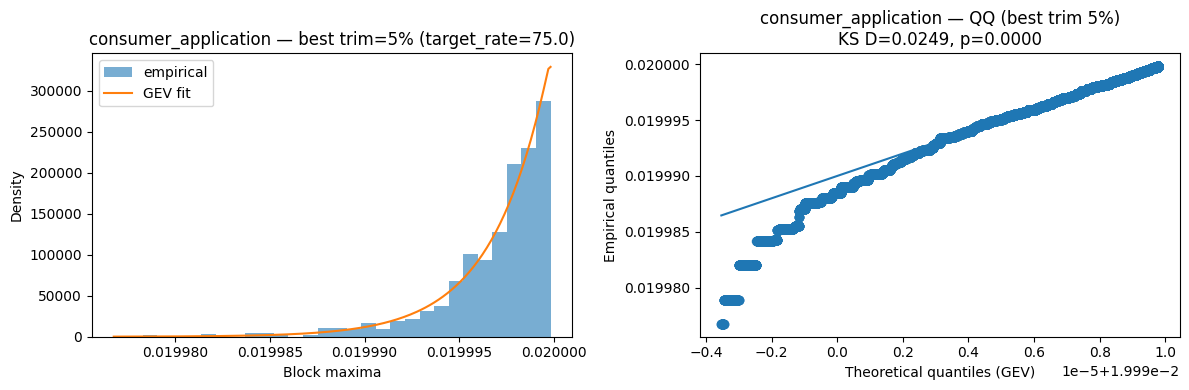

[PLOT] Saved /Users/soheila/PycharmProjects/PipelineProject/RealTime-Streaming-Pipeline/results/plots/best_consumer_application_trim5_tr75.0_global.png

=== producer_application (scope=global, target_rate=75.0) ===
 trim=  0%: n=140085  KS D=0.1492  p=0.0000  (c=-0.4261, loc=1.0538, scale=0.1560)
 trim=  1%: n=138700  KS D=0.1418  p=0.0000  (c=-0.3874, loc=1.0520, scale=0.1493)
 trim=  2%: n=137312  KS D=0.1332  p=0.0000  (c=-0.3446, loc=1.0504, scale=0.1426)
 trim=  5%: n=133149  KS D=0.0907  p=0.0000  (c=-0.1578, loc=1.0484, scale=0.1214)
 trim=  7%: n=130485  KS D=0.0237  p=0.0000  (c=+0.2785, loc=1.0661, scale=0.1144)
 trim= 10%: n=126144  KS D=0.3098  p=0.0000  (c=+1.4508, loc=1.1076, scale=0.3110)


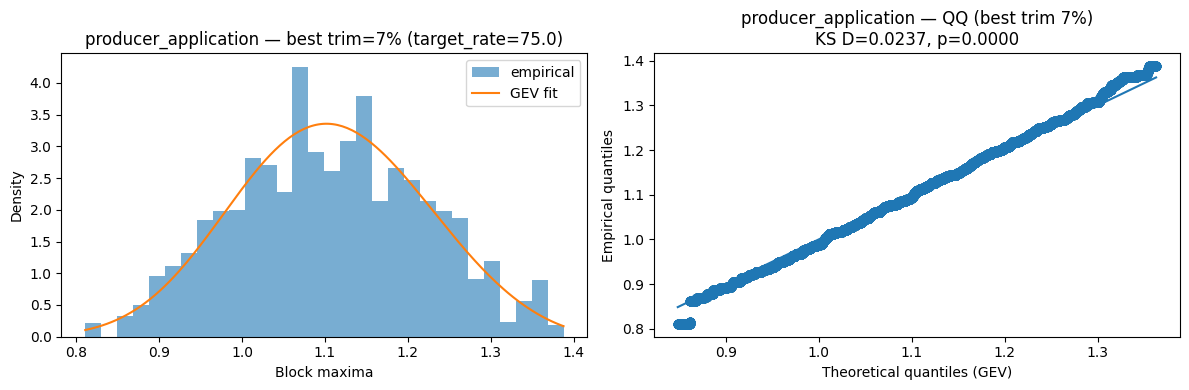

[PLOT] Saved /Users/soheila/PycharmProjects/PipelineProject/RealTime-Streaming-Pipeline/results/plots/best_producer_application_trim7_tr75.0_global.png

=== Best trim per metric (by KS p-value) ===
producer_consumer       trim= 7%  n=130485  KS D=0.0248  p=0.0000  c=+0.2870  loc=1.0542  scale=0.1147
consumer_application    trim= 5%  n=133151  KS D=0.0249  p=0.0000  c=+0.9961  loc=0.0200  scale=0.0000
producer_application    trim= 7%  n=130485  KS D=0.0237  p=0.0000  c=+0.2785  loc=1.0661  scale=0.1144


In [317]:
# ---------- Trim search & plotting ----------

results  = []
plot_dir = os.path.join(Home, "plots")
os.makedirs(plot_dir, exist_ok=True)

for metric in metrics:
    raw = block_df.loc[block_df["metric"] == metric, "block_max_value"].dropna().astype(float).values
    if raw.size < 10:
        print(f"⚠️ Not enough data for {metric} (n={raw.size}). Skipping.")
        continue

    best = None  # (p, D, c, loc, scale, pct, n)
    print(f"\n=== {metric} (scope={SCOPE}, target_rate={TARGET_RATE}) ===")
    for pct in trim_levels:
        x = trim_top_pct(raw, pct)
        if x.size < 10:
            print(f" trim={pct:>4.0%}: n={x.size:4d}  -> skip (too few)")
            continue
        c, loc, scale, D, p = fit_and_ks(x)
        print(f" trim={pct:>4.0%}: n={x.size:4d}  KS D={D:0.4f}  p={p:0.4f}  (c={c:+.4f}, loc={loc:.4f}, scale={scale:.4f})")
        if (best is None) or (p > best[0]):
            best = (p, D, c, loc, scale, pct, x.size)

    if best is None:
        continue
    p, D, c, loc, scale, pct, n = best
    results.append({
        "metric": metric, "best_trim": pct, "n": n,
        "KS_D": D, "KS_p": p, "c": c, "loc": loc, "scale": scale
    })

    # plot ONLY best trim
    xdat = trim_top_pct(raw, pct)
    fig = plt.figure(figsize=(12,4))

    # PDF overlay
    ax1 = plt.subplot(1,2,1)
    xx = np.linspace(float(np.min(xdat)), float(np.max(xdat)), 200)
    pdf = genextreme.pdf(xx, c, loc=loc, scale=scale)
    ax1.hist(xdat, bins=30, density=True, alpha=0.6, label="empirical")
    ax1.plot(xx, pdf, label="GEV fit")
    ax1.set_title(f"{metric} — best trim={int(pct*100)}% (target_rate={TARGET_RATE})")
    ax1.set_xlabel("Block maxima"); ax1.set_ylabel("Density"); ax1.legend()
    # QQ
    ax2 = plt.subplot(1,2,2)
    emp_q  = np.sort(xdat)
    theo_q = genextreme.ppf(np.linspace(0.01, 0.99, len(emp_q)), c, loc=loc, scale=scale)
    ax2.scatter(theo_q, emp_q, alpha=0.6)
    lo, hi = np.nanmin(theo_q), np.nanmax(theo_q)
    ax2.plot([lo, hi], [lo, hi])
    ax2.set_title(f"{metric} — QQ (best trim {int(pct*100)}%)\nKS D={D:.4f}, p={p:.4f}")
    ax2.set_xlabel("Theoretical quantiles (GEV)"); ax2.set_ylabel("Empirical quantiles")

    plt.tight_layout()
    out_path = os.path.join(plot_dir, f"best_{metric}_trim{int(pct*100)}_tr{TARGET_RATE}_{SCOPE}.png")
    plt.savefig(out_path, dpi=150)
    plt.show()
    print(f"[PLOT] Saved {out_path}")
    
# quick summary
if results:
    print("\n=== Best trim per metric (by KS p-value) ===")
    for r in results:
        print(f"{r['metric']:22s}  trim={int(r['best_trim']*100):2d}%  n={r['n']:4d}  "
              f"KS D={r['KS_D']:.4f}  p={r['KS_p']:.4f}  "
              f"c={r['c']:+.4f}  loc={r['loc']:.4f}  scale={r['scale']:.4f}")
else:
    print("No results to summarize.")